# **RAG 구축하기_벡터DB 구성과 RAG 파이프라인 구축1 : 기본 절차 익히기**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(langchain)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [2]:
!pip install langchain langchain-community langchain-openai chromadb tiktoken -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.5 MB/s eta 0:0

#### 2) 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import os
import openai

from langchain.document_loaders import PyMuPDFLoader
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langchain.chains import RetrievalQA
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage, AIMessage
from langchain.chains import ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### (3) OpenAI API Key 등록
* 환경변수로 key 등록

In [4]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [5]:
print(os.environ['OPENAI_API_KEY'][:40])

sk-proj-9_V5Db5A_3EzpkFeDNheztR-ns32fKi-


## 2.Vector DB 구성

**Vector DB**
- 대규모 텍스트 데이터 및 임베딩 벡터를 저장, 검색용

**Vector DB 구축 절차**
- 텍스트 추출 : Loader
    - 다양한 문서(word, pdf, web page 등)로 부터 텍스트 추출하기
- 텍스트 분할 : Splitter
    - chunk 단위로 분할
    - Document 객체로 만들기
- 텍스트 벡터화 : Text Embedding
- Vector DB로 저장 : Vector Store


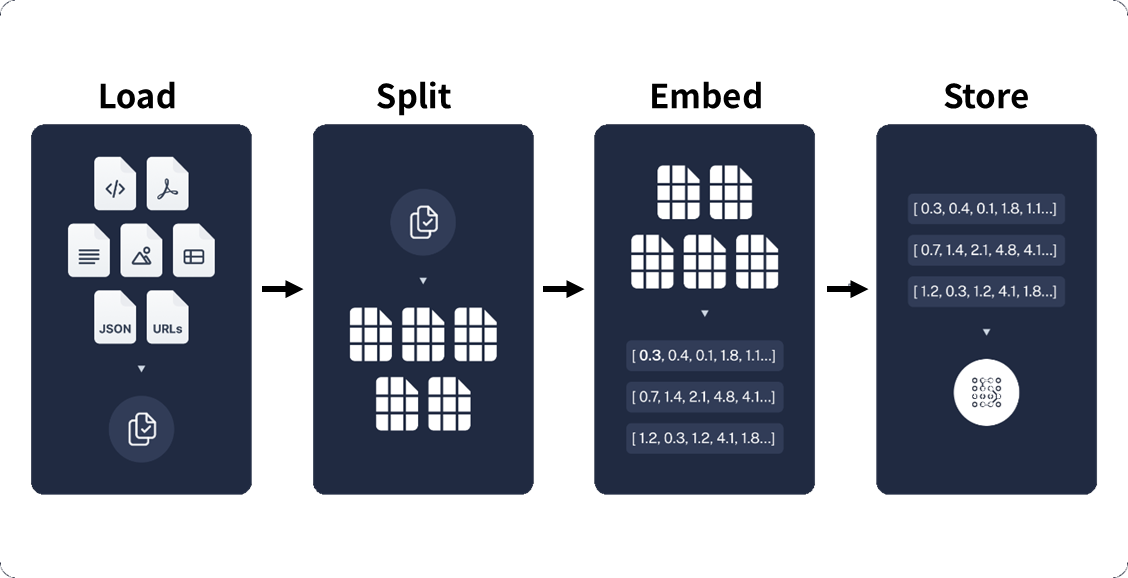


### (1) Loader

- 다양한 소스에서 문서를 불러오고 처리하는 과정을 담당
    - 사전지식이 필요한 지식 기반의 태스크, 정보 검색, 데이터 처리 작업 등을 처리할 때 반드시 필요
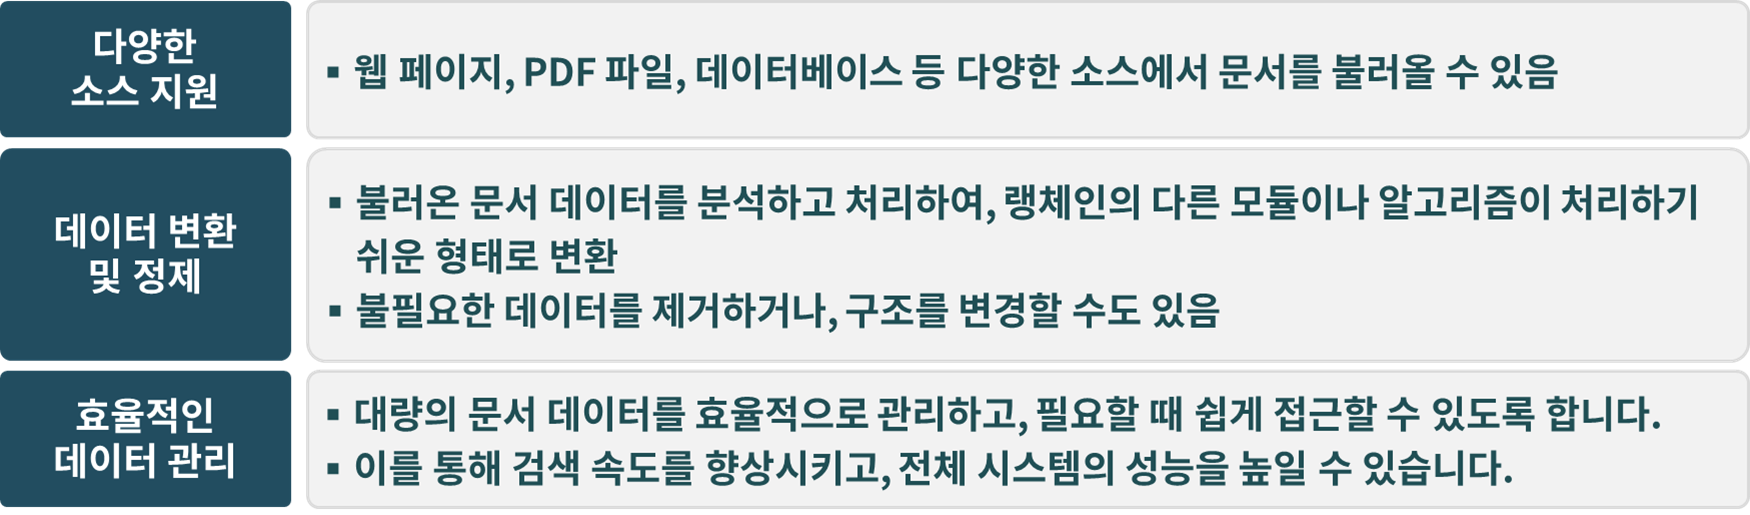

#### 1) TextLoader

- LangChain에서 가장 기본적인 데이터 로더 중 하나
- 일반적인 텍스트 파일(.txt)에서 데이터를 불러오는 역할
- txt 파일을 읽고, 이를 LangChain에서 사용할 수 있는 문서 객체(Document)로 변환


In [7]:
from langchain.document_loaders import TextLoader

# 텍스트 파일 경로 지정
file_path = "상록수.txt"

# TextLoader를 이용하여 문서 로드
loader = TextLoader(path+file_path)
documents = loader.load()

# 로드된 문서 출력
print(documents)

[Document(metadata={'source': '/content/drive/MyDrive/langchain/상록수.txt'}, page_content='심훈 <상록수>\n 쌍두취 행진곡 가을 학기가 되자, ○○일보사에서 주최하는 학생계몽운동에 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그 신문사 누상에서 열린것이다.\n 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.\n 폭양에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리비치는 불빛이 휘황할수록, 흰 벽을 등지고 앉은 그네들의 얼굴은 더한층 검어 보인다.\n 만호 장안의 별처럼 깔린 등불이 한눈에 내려다보이도록 사방의 유리창을 활짝 열 어제 쳤건만, 건장한 청년들의 코와 몸에서 풍기는 훈김이 우거진 콩밭 속에를 들어간 것만치 나후 끈 후끈 끼친다.\n 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다. 지휘자가 손을 내젓는 대로 힘차게 연주하는 것은 유명한 독일 사람의 작곡인 쌍두취 행진곡(雙頭鷲行進曲)이다. 그 활발하고 장쾌한 멜로디는 여러 사람의 심장까지 울리면서 장내의 공기를 진동시킨다.\n 악대의 연주가 끝난 다음에, 사회자인 이 신문사의 편집국장이 안경을 번득이며 점잖은 걸음걸이로 단 위에 나타났다.\n "에― 아직 개학을 아니 헌 학교도 있어서 미처 올라오지 못한 대원이 많을 줄 알었습니다.\n 그런데 뜻밖에 이처럼 성황을 이루어서 장소가 매우 협착한 까닭에, 여러분끼리 서로간 친하는 기회를 드리려는 다과회가 무슨 강연회처럼 되었습니다."\n 하고 일장의 인사를 베푼 뒤에 으흠으흠 하고 헛기침을 해서 목소리를 가다듬더니,\n "금년에는 여러 가지로 지장이 많았는데도 불구하고 작년보다도 거진 곱절이나 되는 놀라울 만한 성적을 보게 됐습니다. 이것은 오직 동족을 사랑하는

* 로딩된 데이터의 타입과 길이를 살펴 봅시다.

In [8]:
print(type(documents))
print(len(documents))
print(type(documents[0]))

<class 'list'>
1
<class 'langchain_core.documents.base.Document'>


In [9]:
documents[0].page_content[:1000]

'심훈 <상록수>\n 쌍두취 행진곡 가을 학기가 되자, ○○일보사에서 주최하는 학생계몽운동에 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그 신문사 누상에서 열린것이다.\n 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.\n 폭양에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리비치는 불빛이 휘황할수록, 흰 벽을 등지고 앉은 그네들의 얼굴은 더한층 검어 보인다.\n 만호 장안의 별처럼 깔린 등불이 한눈에 내려다보이도록 사방의 유리창을 활짝 열 어제 쳤건만, 건장한 청년들의 코와 몸에서 풍기는 훈김이 우거진 콩밭 속에를 들어간 것만치 나후 끈 후끈 끼친다.\n 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다. 지휘자가 손을 내젓는 대로 힘차게 연주하는 것은 유명한 독일 사람의 작곡인 쌍두취 행진곡(雙頭鷲行進曲)이다. 그 활발하고 장쾌한 멜로디는 여러 사람의 심장까지 울리면서 장내의 공기를 진동시킨다.\n 악대의 연주가 끝난 다음에, 사회자인 이 신문사의 편집국장이 안경을 번득이며 점잖은 걸음걸이로 단 위에 나타났다.\n "에― 아직 개학을 아니 헌 학교도 있어서 미처 올라오지 못한 대원이 많을 줄 알었습니다.\n 그런데 뜻밖에 이처럼 성황을 이루어서 장소가 매우 협착한 까닭에, 여러분끼리 서로간 친하는 기회를 드리려는 다과회가 무슨 강연회처럼 되었습니다."\n 하고 일장의 인사를 베푼 뒤에 으흠으흠 하고 헛기침을 해서 목소리를 가다듬더니,\n "금년에는 여러 가지로 지장이 많았는데도 불구하고 작년보다도 거진 곱절이나 되는 놀라울 만한 성적을 보게 됐습니다. 이것은 오직 동족을 사랑하는 여러분의 열성과, 문맹을 한 사람이라도 더 물리치려는 헌신적 노력의 결과인 것이 물론입니다. 그러므로 주 최자측으로서 여러분의 수고를 감사할 뿐 아니라, 우

#### 2) Document

- LangChain에서 텍스트 데이터(문서)를 구조적으로 표현하는 기본 단위
- 주요 속성
    - metadata : 문서의 출처, 태그, 카테고리 등의 부가 정보
    - page_content : 문서의 실제 텍스트 내용
- Loader로 로딩한 후 저장하거나, 직접 Document 생성 가능


In [10]:
from langchain.schema import Document

doc = Document(
    page_content="이것은 LangChain의 Document 객체 예제입니다.",
    metadata={"source": "sample.txt", "category": "example"}
)
doc

Document(metadata={'source': 'sample.txt', 'category': 'example'}, page_content='이것은 LangChain의 Document 객체 예제입니다.')

In [11]:
doc.metadata

{'source': 'sample.txt', 'category': 'example'}

In [12]:
doc.page_content

'이것은 LangChain의 Document 객체 예제입니다.'

In [13]:
text = documents[0].page_content
text

'심훈 <상록수>\n 쌍두취 행진곡 가을 학기가 되자, ○○일보사에서 주최하는 학생계몽운동에 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그 신문사 누상에서 열린것이다.\n 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.\n 폭양에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리비치는 불빛이 휘황할수록, 흰 벽을 등지고 앉은 그네들의 얼굴은 더한층 검어 보인다.\n 만호 장안의 별처럼 깔린 등불이 한눈에 내려다보이도록 사방의 유리창을 활짝 열 어제 쳤건만, 건장한 청년들의 코와 몸에서 풍기는 훈김이 우거진 콩밭 속에를 들어간 것만치 나후 끈 후끈 끼친다.\n 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다. 지휘자가 손을 내젓는 대로 힘차게 연주하는 것은 유명한 독일 사람의 작곡인 쌍두취 행진곡(雙頭鷲行進曲)이다. 그 활발하고 장쾌한 멜로디는 여러 사람의 심장까지 울리면서 장내의 공기를 진동시킨다.\n 악대의 연주가 끝난 다음에, 사회자인 이 신문사의 편집국장이 안경을 번득이며 점잖은 걸음걸이로 단 위에 나타났다.\n "에― 아직 개학을 아니 헌 학교도 있어서 미처 올라오지 못한 대원이 많을 줄 알었습니다.\n 그런데 뜻밖에 이처럼 성황을 이루어서 장소가 매우 협착한 까닭에, 여러분끼리 서로간 친하는 기회를 드리려는 다과회가 무슨 강연회처럼 되었습니다."\n 하고 일장의 인사를 베푼 뒤에 으흠으흠 하고 헛기침을 해서 목소리를 가다듬더니,\n "금년에는 여러 가지로 지장이 많았는데도 불구하고 작년보다도 거진 곱절이나 되는 놀라울 만한 성적을 보게 됐습니다. 이것은 오직 동족을 사랑하는 여러분의 열성과, 문맹을 한 사람이라도 더 물리치려는 헌신적 노력의 결과인 것이 물론입니다. 그러므로 주 최자측으로서 여러분의 수고를 감사할 뿐 아니라, 우

### (2) Splitter

- 긴 문서를 작은 단위인 청크(chunk)로 나누는 텍스트 분리 도구
    - 텍스트를 분리하는 작업 : 청킹(chunking)
        - LLM 모델의 입력 토큰의 개수가 정해져 있기 때문
        - 텍스트가 너무 긴 경우에는 핵심 정보 이외에 불필요한 정보들이 많이 포함  RAG 품질 저하 요인
        - 핵심 정보가 유지될 수 있는 적절한 크기로 나누는 것이 매우 중요
        
**분할시 고려사항**
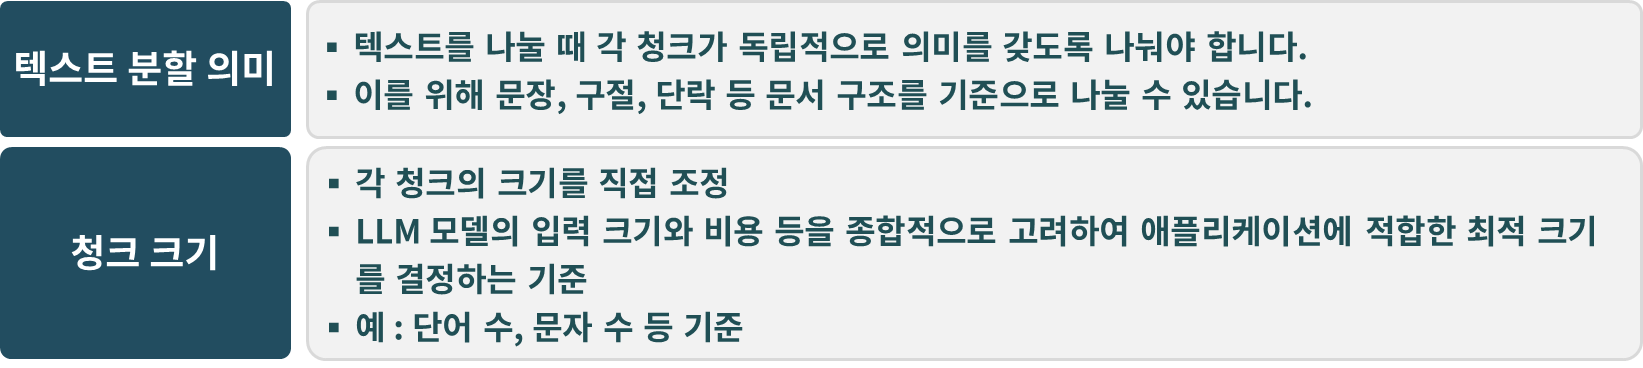

In [14]:
from langchain.text_splitter import CharacterTextSplitter

#### 1) 글자 단위

In [15]:
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '',   # 어떤 기준 없이 무조건 500자 단위로 나누라
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

청크 1, 길이 500: 심훈 <상록수>
 쌍두취 행진곡 가을 학기가 되자, ○○일보사에서 주최하는 학생계몽운동에 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그 신문사 누상에서 열린것이다.
 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.
 폭양에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리비치는 불빛이 휘황할수록, 흰 벽을 등지고 앉은 그네들의 얼굴은 더한층 검어 보인다.
 만호 장안의 별처럼 깔린 등불이 한눈에 내려다보이도록 사방의 유리창을 활짝 열 어제 쳤건만, 건장한 청년들의 코와 몸에서 풍기는 훈김이 우거진 콩밭 속에를 들어간 것만치 나후 끈 후끈 끼친다.
 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다. 지휘자가 손을 내젓는 대로 힘차게 연주하는 것은 유명한 독일 사

청크 2, 길이 500: 끈 끼친다.
 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다. 지휘자가 손을 내젓는 대로 힘차게 연주하는 것은 유명한 독일 사람의 작곡인 쌍두취 행진곡(雙頭鷲行進曲)이다. 그 활발하고 장쾌한 멜로디는 여러 사람의 심장까지 울리면서 장내의 공기를 진동시킨다.
 악대의 연주가 끝난 다음에, 사회자인 이 신문사의 편집국장이 안경을 번득이며 점잖은 걸음걸이로 단 위에 나타났다.
 "에― 아직 개학을 아니 헌 학교도 있어서 미처 올라오지 못한 대원이 많을 줄 알었습니다.
 그런데 뜻밖에 이처럼 성황을 이루어서 장소가 매우 협착한 까닭에, 여러분끼리 서로간 친하는 기회를 드리려는 다과회가 무슨 강연회처럼 되었습니다."
 하고 일장의 인사를 베푼 뒤에 으흠으흠 하고 헛기침을 해서 목소리를 가다듬더니,
 "금년에는 여러 가지로 지장이 많았는데도 불구하고 작년보다도 거진 곱절이나 되는 놀라울 

#### 2) 문장 단위

In [16]:
text_splitter = CharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separator="."  # 문장 단위로 분할
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

청크 1, 길이 463: 심훈 <상록수>
 쌍두취 행진곡 가을 학기가 되자, ○○일보사에서 주최하는 학생계몽운동에 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그 신문사 누상에서 열린것이다.
 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.
 폭양에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리비치는 불빛이 휘황할수록, 흰 벽을 등지고 앉은 그네들의 얼굴은 더한층 검어 보인다.
 만호 장안의 별처럼 깔린 등불이 한눈에 내려다보이도록 사방의 유리창을 활짝 열 어제 쳤건만, 건장한 청년들의 코와 몸에서 풍기는 훈김이 우거진 콩밭 속에를 들어간 것만치 나후 끈 후끈 끼친다.
 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다

청크 2, 길이 476: 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다. 지휘자가 손을 내젓는 대로 힘차게 연주하는 것은 유명한 독일 사람의 작곡인 쌍두취 행진곡(雙頭鷲行進曲)이다. 그 활발하고 장쾌한 멜로디는 여러 사람의 심장까지 울리면서 장내의 공기를 진동시킨다.
 악대의 연주가 끝난 다음에, 사회자인 이 신문사의 편집국장이 안경을 번득이며 점잖은 걸음걸이로 단 위에 나타났다.
 "에― 아직 개학을 아니 헌 학교도 있어서 미처 올라오지 못한 대원이 많을 줄 알었습니다.
 그런데 뜻밖에 이처럼 성황을 이루어서 장소가 매우 협착한 까닭에, 여러분끼리 서로간 친하는 기회를 드리려는 다과회가 무슨 강연회처럼 되었습니다."
 하고 일장의 인사를 베푼 뒤에 으흠으흠 하고 헛기침을 해서 목소리를 가다듬더니,
 "금년에는 여러 가지로 지장이 많았는데도 불구하고 작년보다도 거진 곱절이나 되는 놀라울 만한 성적을 보게 됐습니다

청크 3, 길이 402: 이것은 오직 동족을 사랑하는

#### 3) 줄 바꿈 단위

In [17]:
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

청크 1, 길이 406: 심훈 <상록수>
 쌍두취 행진곡 가을 학기가 되자, ○○일보사에서 주최하는 학생계몽운동에 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그 신문사 누상에서 열린것이다.
 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.
 폭양에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리비치는 불빛이 휘황할수록, 흰 벽을 등지고 앉은 그네들의 얼굴은 더한층 검어 보인다.
 만호 장안의 별처럼 깔린 등불이 한눈에 내려다보이도록 사방의 유리창을 활짝 열 어제 쳤건만, 건장한 청년들의 코와 몸에서 풍기는 훈김이 우거진 콩밭 속에를 들어간 것만치 나후 끈 후끈 끼친다.

청크 2, 길이 411: 정각이 되자 P학당의 취주악대는 코넷, 트럼본 같은 번쩍거리는 악기를 들고 연단 앞줄에가 벌려 선다. 지휘자가 손을 내젓는 대로 힘차게 연주하는 것은 유명한 독일 사람의 작곡인 쌍두취 행진곡(雙頭鷲行進曲)이다. 그 활발하고 장쾌한 멜로디는 여러 사람의 심장까지 울리면서 장내의 공기를 진동시킨다.
 악대의 연주가 끝난 다음에, 사회자인 이 신문사의 편집국장이 안경을 번득이며 점잖은 걸음걸이로 단 위에 나타났다.
 "에― 아직 개학을 아니 헌 학교도 있어서 미처 올라오지 못한 대원이 많을 줄 알었습니다.
 그런데 뜻밖에 이처럼 성황을 이루어서 장소가 매우 협착한 까닭에, 여러분끼리 서로간 친하는 기회를 드리려는 다과회가 무슨 강연회처럼 되었습니다."
 하고 일장의 인사를 베푼 뒤에 으흠으흠 하고 헛기침을 해서 목소리를 가다듬더니,

청크 3, 길이 450: 하고 일장의 인사를 베푼 뒤에 으흠으흠 하고 헛기침을 해서 목소리를 가다듬더니,
 "금년에는 여러 가지로 지장이 많았는데도 불구하고 작년보다도 거진 곱절이나 되는 놀라울 만한 성적을 보게 됐습니다. 이것은 오직 동족을 사랑하는 여러분의 열성과, 

#### 4) 실습
* 다음의 옵션을 자유롭게 조절하며 청크의 크기가 어떻게 나뉘는지 살펴 봅시다.
    * chunk_size
    * chunk_overlap
    * separator

In [18]:
text_splitter = CharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap  = 50,
    separator = '',
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

청크 1, 길이 99: 심훈 <상록수>
 쌍두취 행진곡 가을 학기가 되자, ○○일보사에서 주최하는 학생계몽운동에 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그

청크 2, 길이 100: 참가하였던 대원들이 돌아왔다. 오늘 저녁은 각처에서 모여든 대원들을 위로하는 다과회가 그 신문사 누상에서 열린것이다.
 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡

청크 3, 길이 100: 신문사 누상에서 열린것이다.
 오륙백 명이나 수용할 수 있는 대강당에는 전 조선의 방방곡곡으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.
 폭양

청크 4, 길이 100: 으로 흩어져서 한여름 동안 땀을 흘려 가며 활동한 남녀 대원들로 빈틈없이 들어찼다.
 폭양에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리

청크 5, 길이 100: 에 그을은 그들의 시커먼 얼굴! 큰 박덩이만큼씩 한 전등이 드문드문하게 달린 천장에서 내리비치는 불빛이 휘황할수록, 흰 벽을 등지고 앉은 그네들의 얼굴은 더한층 검어 보인다.
 만



### (3) Embedding & Store

**임베딩(Embedding)**
- 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 과정.
- 이때, 의미적인 정보를 보존하도록 설계

**임베딩 목적**
- 벡터 표현을 사용하면, 텍스트 데이터를 벡터 공간 내에서 수학적으로 다룰 수 있게 됨
- 이를 통해 텍스트 간의 유사성을 계산 가능
- 텍스트 데이터를 기반으로 하는 다양한 머신러닝 및 자연어 처리 작업 수행

**임베딩 모델 사용**
- Openai : text-embedding-3-small

**벡터 저장소(Vector Store)**
- 벡터 형태로 표현된 데이터, 즉 임베딩 벡터들을 효율적으로 저장하고 검색할 수 있는 DB
- Vector DB라고 불림 (대표적인 Vector DB : Chroma, FAISS)

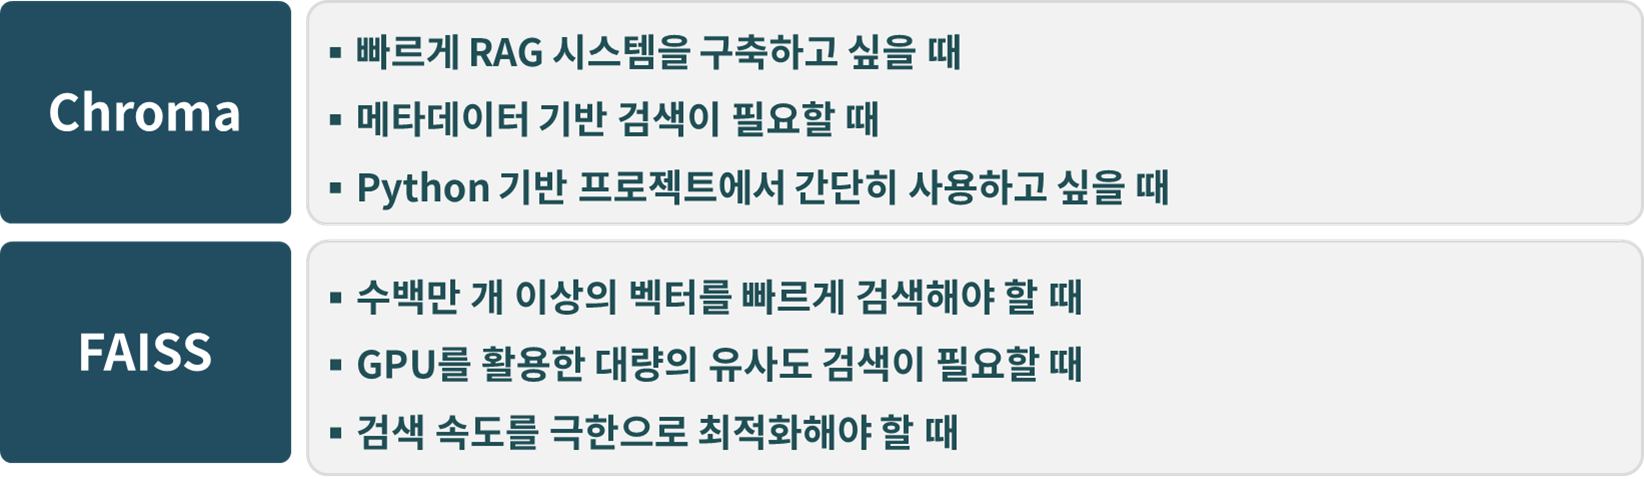



#### 1) Embedding model 선언

In [19]:
from langchain.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [20]:
sample_text1 = "농촌 계몽운동은 한국 근대화의 중요한 과정이었다."
vector1 = embedding_model.embed_query(sample_text1)

# 벡터 길이 및 일부 값 확인
print(f"임베딩 벡터 길이: {len(vector1)}")
print(f"첫 10개 벡터 값: {vector1[:10]}")

임베딩 벡터 길이: 1536
첫 10개 벡터 값: [0.07032494958766337, 0.04317136833520823, 0.02828329788186392, 0.059632975326150695, -0.019770065229040498, 0.01054067252807862, 0.009027657987705698, 0.024248590578224323, 0.003096637767067749, -0.018347831356198985]


* [참조] 두 문장이 얼마나 유사한지 코사인 유사도로 계산해 봅시다.

* ***코사인 유사도란?***
    * 수학적 의미 : 두 단위 벡터의 내적
    * NLP에서의 의미 : 유사한 벡터 -> 유사한 문맥적 의미
        * 1에 가까울수록 유사하다는 의미
        * 0이면 관계가 없다는 의미
        * -1이면 반대된다는 의미

In [21]:
sample_text2 = "대한민국의 근대화에 농촌 개혁 운동은 큰 영향을 미쳤다."
vector2 = embedding_model.embed_query(sample_text2)

In [22]:
from numpy.linalg import norm
# vector1, vector2 코사인 유사도 계산
def cosine_similarity(vec1, vec2):
    return float(np.dot(vec1, vec2) / (norm(vec1) * norm(vec2)))

# 두 문장의 코사인 유사도 계산
similarity_score = cosine_similarity(vector1, vector2)
similarity_score

0.6029888704750458

#### 2) ChromaDB 저장

In [23]:
# 다시 분할하자.
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_texts = text_splitter.split_text(text)

In [24]:
from langchain.vectorstores import Chroma

# ChromaDB를 만들면서 저장
vectorstore = Chroma.from_texts(split_texts, embedding_model, persist_directory="./chroma_db")

### (4) 유사도 검색

In [25]:
query = "농촌 계몽운동에 대한 내용"
retrieved_docs = vectorstore.similarity_search(query, k=3)

# 결과 출력
print("검색 결과:")
for doc in retrieved_docs:
    print(doc.page_content)
    print('-'*200)

검색 결과:
하는 감상이 들었다. 그는 그러한 지도분자들과 굳게 악수를 하고 하룻밤씩 같이 자면서 의견을 교환하고 새로운 방침을 토론도 하였다. 어느 곳에를 가나,
 "지금 우리의 형편으로는 계몽적인 문화운동도 해야 하지만, 무슨 일에든지 토대가 되는 경제 운동이 더욱 시급하다."
 는 것을 역설하고 저의 경험을 이야기하였다.
 그러는 동시에 그는, ' 이제부터 한곡리에만 들어앉었을 게 아니라 다시 일에 기초가 잡히기만 하면, 전 조선의 방방곡곡으로 돌아다니며 널리 듣고 보기도 하고, 또는 내 주의와 주장을 세워 보리라. 그네들과 긴밀한 연락을 취해서 같은 정신과 계획 아래에서 농촌운동을 통일시키도록 힘써 보리라.’
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
"재청요―---"
 "앙코르―--- 앙코르 ―--- "하는 소리가 여기저기서 일어나며 회장 안은 벌통 속처럼 와글와글한다. S군은 저더러 잘 한다는 줄만 알고, 두번 세번 껑충거리고 나와서 익살을 깨트리는 바람에 점잔을 빼던 사회자도 간신히 웃음을 참고 앉았다. 그는 미소를 띠고 일어서며,
 "여러분 고만 조용헙시다."
 하고 손을 들었다.
 "지금부터 여러분의 체험담을 듣겠습니다. 한 사람도 빼어 놓지 않고 고향에서 활동 하던 이야기를 골고루 듣고는 싶지만, 시간이 허락지 않는 관계로 유감천만이나 사회자가 몇 분을 지적할 수밖에 없습니다."
 하고 양복 주머니에서 각 지방으로부터 온 통신과, 이미 신문에 발표된 대원들의 보고서를 한 뭉텅이나 꺼내 놓고 뒤적 거리 더니,
 "금년에 활동한 계몽 대원 중에 뛰어나게 좋은 성적을 보여 주었을 뿐 아니라, 글을 깨쳐 준 아동의 수효로는 우리 신문사에서

* 실습

몇가지 질문을 던저서 적절한 문서를 가져오는지 확인해보자

In [26]:
query = "동혁과 영신의 만남"
retrieved_docs = vectorstore.similarity_search(query, k=3)

# 결과 출력
print("검색 결과:")
for doc in retrieved_docs:
    print(doc.page_content)
    print('-'*200)

검색 결과:
동혁이도 영신을 놀리며 청석골 교회의 장로처럼 합장을 하고 일부러 목소리를 떨어,
 "오 ― 전지전능하신 하나님, 감사감사하나이다."
 하고는 껄껄껄 웃어제친다.
 "그렇게 하나님을 놀리면 천벌이 내리는 법이야요. 아무튼 나 같은 사람을 영영 버리지 않으시구 이만침이나 낫게 해주신 게 다 하나님의 뜻이지 뭐야요."
 
 하고 영신은 사랑하는 사람을 곁눈으로 살짝 흘겨본다. 영신이가 평소에 동혁에게 대한 다만 한 가지 불평은 저와 같이 예수를 믿지 않는 것이다. 부모형제간에도 종교를 믿는 것은 절대 자유요, 신앙은 강제로 할 수 없는 것인 줄 알면서도, 이 세상을 톡톡 털어도 단지 한 사람인 저의 애인이, 저와 똑같은 믿음을 가졌으면 얼마나 좋을는지 몰랐다. 믿지를 않으면 국으로 가만히나 있지를 않고, 제가 밥상 앞에서 눈을 내리감고 기도를 올릴 때면 곁에서 일부러 헛기침을 칵칵 하기, 김이 무럭무럭 나는 찌개 냄비를 코밑에다 들여대기가 일쑤다. 그럴 때면,
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
동혁은 두번 세번 읽으며 편지를 손에서 놓을 줄 몰랐다.
 *
 영신은 그날 밤 그가 숭배하는 백씨에게 백 퍼센트로 동혁을 소개하였었다. 어쩌면 동 혁이가 영신에게 대한 것보다, 그 이상으로 '박동혁’이란 인물의 첫인상이 깊었는지도 모른다.
 그 구릿빛 같은 얼굴, 황소처럼 건강한 체격, 거기다가 조금도 꾸밀 줄은 모르면서도 혀끝으로 불길을 뿜어 내는 듯한 열변, 그리고 비록 처음 만났으나마 어두운 길거리로 제 뒤를 따라다니며 보호해 주면서도, 조그만치도 비굴하거나 지나친 친절을 보이지 않던 그 점잖은 몸가짐.
 영신이가 입에 침이 말라서 동

## 3.RAG 파이프라인

* 순서
    * (1) Retriever 선언
        - Vector DB에서 사용자의 질문과 가장 유사한 문서(청크)를 검색
        - 코사인 유사도(Cosine Similarity) 기반으로 유사한 문서 검색
    * (2) llm 모델 지정
        - 검색된 문서와 함께 질문을 받아 답변 생성할 LLM 모델 지정
    * (3) 메모리 선언
        - 대화의 흐름을 유지하고, 이전 질문을 기억하여 문맥을 제공
        - 프롬프트 길이를 고려한 메모리 최적화 필요        
    * (4) 체인 함수로 엮기
        - Retriever + LLM + Memory를 하나의 체인으로 연결하여 질문-응답 시스템 완성
    

### (1) RAG 파이프라인 구축

In [27]:
# (1) 리트리버(Retriever) 생성
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

# (2) GPT-4.1-mini 모델 설정
llm = ChatOpenAI(model_name="gpt-4.1-mini")

# (3) 메모리 추가 (대화 문맥 유지)
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True, output_key="answer")

# (4) RAG 기반 ConversationalRetrievalChain 구성
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    memory=memory,
    return_source_documents=False  # 검색된 문서 출력 옵션
)

### (2) RAG 파이프라인 사용

In [28]:
# 테스트 실행
query = "동혁과 영신이 하고자 했던 농촌 계몽 운동 중 가장 중요한게 뭐야?"
response = qa_chain({"question": query})

# 응답 출력
print("답변:", response["answer"])

답변: 동혁과 영신이 하고자 했던 농촌 계몽 운동 중 가장 중요한 것은 단순히 글자를 가르치는 데 그치지 않고, 농민들의 살 길을 열어주기 위한 실천적인 운동이었다는 점입니다. 동혁은 농촌 운동일수록 무엇보다 실천이 중요하다고 강조했으며, 단순히 명령만 내리는 상관이 아니라 앞장서서 모범을 보이는 참여자가 되어야 운동이 성공할 수 있다고 말했습니다. 즉, 농민들의 삶을 개선하고 희망의 정신을 심어주는 실질적인 변화를 목표로 하는 것이 가장 중요한 부분입니다.


In [29]:
# 테스트 실행
query = "동혁과 영신은 처음 어디에서 만났어?"
response = qa_chain({"question": query})

# 응답 출력
print("답변:", response["answer"])

답변: 주어진 글에는 동혁과 영신이 처음 만난 장소에 대한 구체적인 언급이 없습니다. 따라서 두 사람이 처음 만난 장소가 어디인지는 알 수 없습니다.


In [30]:
for message in qa_chain.memory.chat_memory.messages:
    print(f"{message.type}: {message.content}")

human: 동혁과 영신이 하고자 했던 농촌 계몽 운동 중 가장 중요한게 뭐야?
ai: 동혁과 영신이 하고자 했던 농촌 계몽 운동 중 가장 중요한 것은 단순히 글자를 가르치는 데 그치지 않고, 농민들의 살 길을 열어주기 위한 실천적인 운동이었다는 점입니다. 동혁은 농촌 운동일수록 무엇보다 실천이 중요하다고 강조했으며, 단순히 명령만 내리는 상관이 아니라 앞장서서 모범을 보이는 참여자가 되어야 운동이 성공할 수 있다고 말했습니다. 즉, 농민들의 삶을 개선하고 희망의 정신을 심어주는 실질적인 변화를 목표로 하는 것이 가장 중요한 부분입니다.
human: 동혁과 영신은 처음 어디에서 만났어?
ai: 주어진 글에는 동혁과 영신이 처음 만난 장소에 대한 구체적인 언급이 없습니다. 따라서 두 사람이 처음 만난 장소가 어디인지는 알 수 없습니다.


## 4.종합실습

* 인사규정 챗봇을 만들어 봅시다.
    * 주어진 파일 "인사관리규정.txt"을 로딩
    * 적절한 크기로 split
    * chroma DB에 저장
    * RAG 구성 :
        * 요약 메모리 연결
        

In [32]:
# 1. 텍스트 로딩
from langchain.document_loaders import TextLoader

loader = TextLoader(path + "인사관리규정.txt")
documents = loader.load()

In [33]:
text = documents[0].page_content
text

'인사관리규정\n\n제1장 총칙\n\n제1조【목적】 \n이 규정은 당사 직원에 적용할 인사관리의 기본기준과 절차를 정하여 공정하고 합리적인 인사업무처리에 기여함을 목적으로 한다. \n\n제2조【적용범위】 \n직원의 인사에 관하여 다른 규정에 특별히 정한 것을 제외하고는 이 규정에 따른다. \n\n제3조【직원의 구분】 \n회사의 직원은 간부직, 일반직, 별정직, 기능직, 임시직, 일용직 직원으로 구분한다.\n\n제4조【직급의 구분】 \n사원의 직급은 1급 : 부장, 2급 : 차장, 3급 : 과장, 4급 : 대리, 5급 : 주임, 6급 : 대졸사원, 7급 : 고졸사원 등으로 구분하며 동일직급에서 갑, 을, 병으로 세분할 수 있다.\n\n제2장 인사위원회\n\n제5조【인사위원회】 \n①직원의 인사에 관한 사항을 심의하기 위하여 본사에 인사위원회를 둔다. \n②인사위원회의 구성은 위원장을 포함하여 ○인 이상 ○인 이내로 하되, 위원장 및 위원은 사장이 필요시에 임명하며, 간사는 인사담당부서장이 된다. \n③인사위원회의 설치 및 운영에 관한 세부사항은 인사위원회 규정에서 따로 정한다.\n\n제6조【인사위원회의 기능】 \n인사위원회는 다음 각 호의 사항을 심의, 의결한다.\n1. 인사제도의 수립, 변경 등에 관한 사항 및 인사관련 중요기본방침에 관한 사항\n2. 직원의 채용, 임명, 승진, 표창, 징계, 해고 관련사항\n3. 다른 규정에서 위임된 사항\n4. 기타 사장이 필요하다고 인정하는 사항\n\n제3장 채용과 시험\n\n제7조【신규채용】 \n직원의 신규채용은 공개경쟁시험을 원칙으로 하되 필요한 경우 특별 채용할 수도 있다. \n\n제8조【임용권자】 \n직원에 대한 임용권 일체는 사장이 가지되 필요한 경우 그 일부를 하위자에게 위임할 수 있다.\n\n제9조【채용결격사유】 \n다음 각 호에 해당하는 자는 직원으로 채용하여서는 아니된다.\n 1. 금치산자 또는 한정치산자\n 2. 파산된 자로서 복권되지 아니한 자\n 3. 금고이상의 형을 받고 그 집행이 종료되거나 집행을

In [34]:
# 2. 청킹
text_splitter = CharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap  = 50,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

청크 1, 길이 223: 인사관리규정
제1장 총칙
제1조【목적】 
이 규정은 당사 직원에 적용할 인사관리의 기본기준과 절차를 정하여 공정하고 합리적인 인사업무처리에 기여함을 목적으로 한다. 
제2조【적용범위】 
직원의 인사에 관하여 다른 규정에 특별히 정한 것을 제외하고는 이 규정에 따른다. 
제3조【직원의 구분】 
회사의 직원은 간부직, 일반직, 별정직, 기능직, 임시직, 일용직 직원으로 구분한다.
제4조【직급의 구분】

청크 2, 길이 266: 제4조【직급의 구분】 
사원의 직급은 1급 : 부장, 2급 : 차장, 3급 : 과장, 4급 : 대리, 5급 : 주임, 6급 : 대졸사원, 7급 : 고졸사원 등으로 구분하며 동일직급에서 갑, 을, 병으로 세분할 수 있다.
제2장 인사위원회
제5조【인사위원회】 
①직원의 인사에 관한 사항을 심의하기 위하여 본사에 인사위원회를 둔다. 
②인사위원회의 구성은 위원장을 포함하여 ○인 이상 ○인 이내로 하되, 위원장 및 위원은 사장이 필요시에 임명하며, 간사는 인사담당부서장이 된다.

청크 3, 길이 292: ③인사위원회의 설치 및 운영에 관한 세부사항은 인사위원회 규정에서 따로 정한다.
제6조【인사위원회의 기능】 
인사위원회는 다음 각 호의 사항을 심의, 의결한다.
1. 인사제도의 수립, 변경 등에 관한 사항 및 인사관련 중요기본방침에 관한 사항
2. 직원의 채용, 임명, 승진, 표창, 징계, 해고 관련사항
3. 다른 규정에서 위임된 사항
4. 기타 사장이 필요하다고 인정하는 사항
제3장 채용과 시험
제7조【신규채용】 
직원의 신규채용은 공개경쟁시험을 원칙으로 하되 필요한 경우 특별 채용할 수도 있다. 
제8조【임용권자】

청크 4, 길이 293: 제8조【임용권자】 
직원에 대한 임용권 일체는 사장이 가지되 필요한 경우 그 일부를 하위자에게 위임할 수 있다.
제9조【채용결격사유】 
다음 각 호에 해당하는 자는 직원으로 채용하여서는 아니된다.
 1. 금치산자 또는 한정치산자
 2. 파산된 자로서 복권되지 아니한 자
 3. 금고

In [35]:
# 3. 임베딩 및 Chroma에 저장
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
db = Chroma.from_texts(split_texts, embedding, persist_directory="./hr_rule")

In [36]:
from langchain.chains import ConversationalRetrievalChain
from langchain.memory import ConversationSummaryMemory
from langchain.chat_models import ChatOpenAI

# 4. 구성요소 준비
llm = ChatOpenAI(temperature=0.1, model="gpt-4.1-mini")

retriever = db.as_retriever(search_type="similarity", search_kwargs={"k": 3})

memory = ConversationSummaryMemory(
    llm=llm,
    memory_key="chat_history",
    return_messages=True,
    output_key="answer"
)

# 6. ConversationalRetrievalChain
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,       # 기존 Chroma DB retriever
    memory=memory,
    return_source_documents=True,
    # output_key="answer"  # ConversationalRetrievalChain은 기본적으로 'answer' key 사용
)

In [37]:
# 7. 질의
query = "신규채용 시 연령 제한이 있나요?"
result = qa_chain({"question": query})

print("답변:")
print(result["answer"])


답변:
네, 신규채용 시 연령 제한이 있습니다. 직원으로 신규채용되는 자의 최고연령은 직급에 따라 다음과 같이 정해져 있습니다.

1. 1급 직원: 50세
2. 2급 직원: 45세
3. 3급 직원: 40세
4. 4급 직원: 35세

따라서 해당 직급에 맞는 연령 이하인 경우에만 신규채용이 가능합니다.
